# 04 — Group Relative Policy Optimization (GRPO)

**Goal:** improve the model with **reinforcement learning** on a task that has a
**verifiable reward** (arithmetic), implementing GRPO from scratch: group
sampling, a group-normalized advantage (no critic), and a clipped policy-gradient
objective with a KL penalty.

This is stage **4**, the only true RL stage. For this task the policy starts from
the **base model** (see the note below), and a frozen copy is the KL reference.
The result is saved to `checkpoints/grpo/`.

> This notebook generates inside the training loop, so it is the slowest — a GPU
> helps, but it still runs on a MacBook (it just needs more time).

## The idea

PPO-style RLHF needs a learned **value network** (critic) to estimate a baseline
for the advantage \(A = r - V(s)\). Training and tuning that critic is a big part
of PPO's complexity.

**GRPO's trick:** for each prompt, sample a *group* of \(G\) responses, score them
all, and use the **group's mean reward as the baseline**:

\[ A_i = \frac{r_i - \operatorname{mean}(r_{1..G})}{\operatorname{std}(r_{1..G}) + \varepsilon} \]

A response that is better than its group's average gets a positive advantage and
is reinforced; a below-average one is suppressed. **No value network is needed** —
the group itself is the baseline (`src/losses.py::group_normalized_advantage`).

It then optimizes a PPO-style **clipped** surrogate with a **KL penalty** to the
frozen reference (`grpo_policy_loss`):

\[ \mathcal{L} = -\,\mathbb{E}\big[\min(\rho_t A,\ \operatorname{clip}(\rho_t, 1\pm\epsilon) A) - \beta_{\text{KL}}\,\mathrm{KL}(\pi_\theta\,\|\,\pi_{\text{ref}})\big],\quad \rho_t = \frac{\pi_\theta}{\pi_{\text{old}}} \]

### Why a *verifiable* reward?

RL needs a reward signal. Here it's **checkable code**, not a learned model: ask
the model to solve `a + b`, have it answer inside `<answer>...</answer>`, and score
it deterministically. A **graded** reward (`src/data.py::arithmetic_reward`)
gives a weak model a usable gradient instead of all-or-nothing:

- +0.1 well-formed `<reasoning>` tags, +0.2 well-formed `<answer>` tags,
- +0.1 for any parseable integer answer, **+1.0 for the correct number** (max 1.4).

Deterministic, cheap, ungameable — exactly the setting where GRPO shines (math,
code, etc.).

### Two practical choices for a tiny model

1. **Training starts from the base model, not the DPO/SFT adapter.** The earlier
   stages specialized the model on the *lumen* domain; that knowledge is
   irrelevant (and actively harmful) for arithmetic. This is the "chained pipeline
   … *where it makes sense*" caveat — here it doesn't, so this stage begins from
   the base model's general competence. (The KL reference is a frozen copy of that
   same base model.)
2. **One-shot prompt.** A 135M model almost never emits the `<answer>` tags
   zero-shot, which would leave every reward at 0 and GRPO with no signal. A single
   worked example (`ARITHMETIC_FEWSHOT`) makes the format appear often enough — with
   sampling variance — for the group-relative advantage to push it up. Empirically
   one-shot ≫ zero- or two-shot for this model.

In [1]:
import sys, pathlib

REPO_ROOT = pathlib.Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.utils import (set_seed, get_device, amp_context, LossLogger,
                       plot_curves, save_lora_checkpoint, load_lora_checkpoint)
from src.lora import inject_lora, lora_parameters, count_parameters
from src.losses import (per_token_logprobs, group_normalized_advantage,
                        grpo_policy_loss)
from src.data import (generate_arithmetic_problems, arithmetic_reward,
                      extract_answer, format_prompt)

set_seed(42)
device = get_device()
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
CKPT_DIR = REPO_ROOT / "checkpoints"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_base_with_lora():
    """Fresh base model + (identity-at-init) LoRA. The DPO/SFT adapter is
    deliberately NOT loaded: those are specialized on the unrelated lumen domain,
    so for the arithmetic task training begins from the base model's competence."""
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
    inject_lora(m, target_modules=("q_proj", "v_proj"), r=8, alpha=16)
    return m.to(device)


policy = build_base_with_lora()
reference = build_base_with_lora()
for p in reference.parameters():
    p.requires_grad_(False)
reference.eval()

trainable, total = count_parameters(policy)
print(f"Device: {device} | policy trainable {trainable:,} / {total:,}")

/Users/jorgesandoval/code/llm-post-training-from-scratch/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device: mps | policy trainable 460,800 / 134,975,808


## The task and the verifiable reward

Problems are generated procedurally (`generate_arithmetic_problems`). The prompt
asks for `<reasoning>` and a final `<answer>`. `arithmetic_reward` scores a
generation deterministically. The reward is sanity-checked below on a few
hand-written completions before any training.

In [2]:
problems = generate_arithmetic_problems(n=200, max_operand=9, ops=("+", "-"), seed=0)
print("Example prompt:\n", problems[0].prompt())
print("Correct answer:", problems[0].answer)

# Reward sanity check (target = 12):
samples = [
    "<reasoning>7 plus 5 is 12</reasoning><answer>12</answer>",  # correct + format
    "The answer is 12.",                                          # correct number, no tags
    "<reasoning>adding them</reasoning><answer>9</answer>",      # format only, wrong
    "no idea",                                                    # nothing
]
for s in samples:
    print(f"  reward={arithmetic_reward(s, 12):.1f}  extracted={extract_answer(s)}  <- {s!r}")

Example prompt:
 ### Instruction:
Solve the problem. Show your reasoning inside <reasoning></reasoning> and give the final number inside <answer></answer>.

What is 2 + 3?
<reasoning>2 plus 3 is 5.</reasoning><answer>5</answer>

What is 6 + 6?

### Response:

Correct answer: 12
  reward=1.4  extracted=12  <- '<reasoning>7 plus 5 is 12</reasoning><answer>12</answer>'
  reward=0.0  extracted=None  <- 'The answer is 12.'
  reward=0.4  extracted=9  <- '<reasoning>adding them</reasoning><answer>9</answer>'
  reward=0.0  extracted=None  <- 'no idea'


## Group sampling

For each prompt, `GROUP` completions are sampled with temperature, each one is
scored, and a **completion mask** is built (1 on generated tokens up to and
including the first EOS, 0 on the prompt and padding) so the loss only touches
tokens the model actually produced.

Note `pad_token == eos_token` for this model, so the mask logic stops at the first
EOS. The demo below shows raw rewards and the resulting **group-normalized
advantages** — within each group they sum to ~0, which is the baseline at work.

In [3]:
@torch.no_grad()
def sample_groups(problems_batch, group_size, max_new_tokens=40, temperature=1.0):
    """Sample `group_size` completions per prompt; return padded tensors + rewards."""
    policy.eval()
    seqs, masks, rewards, texts = [], [], [], []
    eos = tokenizer.eos_token_id
    for prob in problems_batch:
        enc = tokenizer(prob.prompt(), return_tensors="pt").to(device)
        plen = enc["input_ids"].shape[1]
        out = policy.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=True,
            temperature=temperature, top_p=0.95,
            num_return_sequences=group_size, pad_token_id=tokenizer.pad_token_id)
        for i in range(group_size):
            seq = out[i].tolist()
            comp = seq[plen:]
            texts.append(tokenizer.decode(comp, skip_special_tokens=True))
            rewards.append(arithmetic_reward(texts[-1], prob.answer))
            mask, ended = [0] * plen, False     # mask completion up to first EOS
            for tid in comp:
                mask.append(0 if ended else 1)
                if tid == eos:
                    ended = True
            seqs.append(seq)
            masks.append(mask)

    maxlen = max(len(s) for s in seqs)
    pad = tokenizer.pad_token_id
    input_ids = torch.tensor([s + [pad] * (maxlen - len(s)) for s in seqs], device=device)
    attn = torch.tensor([[1] * len(s) + [0] * (maxlen - len(s)) for s in seqs], device=device)
    cmask = torch.tensor([m + [0] * (maxlen - len(m)) for m in masks],
                         dtype=torch.float32, device=device)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
    return input_ids, attn, cmask, rewards, texts


# Demo one group.
demo_probs = problems[:2]
ids, attn, cmask, rew, txt = sample_groups(demo_probs, group_size=4, temperature=1.0)
adv = group_normalized_advantage(rew.view(2, 4)).view(-1)
print("rewards   :", rew.view(2, 4).tolist())
print("advantages:", [round(a, 2) for a in adv.tolist()])
print("\nExample completion (prompt 0):", repr(txt[0][:120]))

rewards   : [[0.10000000149011612, 1.399999976158142, 1.399999976158142, 0.0], [0.0, 0.0, 0.0, 0.4000000059604645]]
advantages: [-0.92, 1.0, 1.0, -1.07, -0.58, -0.58, -0.58, 1.73]

Example completion (prompt 0): 'Solve the problem. Show your reasoning inside <reasoning></reasoning>. Give the final answer in 2 digits.\n\nWhy are the s'


## Training loop

Each GRPO step:
1. Sample groups and score them; compute group-normalized advantages.
2. Cache `old` (sampling-policy) and `ref` (frozen) per-token log-probs.
3. Do a few inner update epochs of the **clipped** surrogate + KL penalty
   (`grpo_policy_loss`), so the importance ratio \(\rho_t\) can move away from 1
   and the clipping actually matters.

**Mean reward** and **fraction correct** are logged per step — the headline GRPO
curve is mean reward rising over time.

In [4]:
STEPS = 40
NUM_PROMPTS = 8       # prompts per step
GROUP = 6             # samples per prompt (the "group")
MAX_NEW_TOKENS = 32
TEMPERATURE = 1.0
INNER_EPOCHS = 2      # PPO-style update epochs per batch of samples
LR = 2e-5
CLIP_EPS = 0.2
KL_COEF = 0.04

optimizer = torch.optim.AdamW(lora_parameters(policy), lr=LR)
logger = LossLogger()


def token_logps(model, input_ids, attn):
    logits = model(input_ids=input_ids, attention_mask=attn).logits
    return per_token_logprobs(logits, input_ids)   # (B, T-1)


import random
rng = random.Random(123)

for step in range(STEPS):
    batch = rng.sample(problems, NUM_PROMPTS)
    input_ids, attn, cmask, rewards, _ = sample_groups(
        batch, GROUP, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)

    advantages = group_normalized_advantage(rewards.view(NUM_PROMPTS, GROUP)).view(-1)
    token_mask = cmask[:, 1:]

    with torch.no_grad():
        old_logps = token_logps(policy, input_ids, attn)
        ref_logps = token_logps(reference, input_ids, attn)

    policy.train()
    for _ in range(INNER_EPOCHS):
        with amp_context(device):
            cur_logps = token_logps(policy, input_ids, attn)
            loss, metrics = grpo_policy_loss(
                cur_logps, old_logps, ref_logps, advantages, token_mask,
                clip_eps=CLIP_EPS, kl_coef=KL_COEF)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_parameters(policy), 1.0)
        optimizer.step()

    frac_correct = (rewards >= 1.0).float().mean().item()
    logger.log(step, mean_reward=rewards.mean().item(),
               frac_correct=frac_correct, kl=metrics["kl"], loss=loss.item())
    if step % 5 == 0 or step == STEPS - 1:
        print(f"step {step:3d} | mean_reward {rewards.mean().item():.3f} "
              f"| correct {frac_correct:.2f} | kl {metrics['kl']:.4f}")

print(f"\nFinal mean reward: {logger.last('mean_reward'):.3f}")

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


step   0 | mean_reward 0.146 | correct 0.04 | kl 0.0000


step   5 | mean_reward 0.212 | correct 0.10 | kl 0.0001


step  10 | mean_reward 0.202 | correct 0.10 | kl 0.0005


step  15 | mean_reward 0.188 | correct 0.08 | kl 0.0010


step  20 | mean_reward 0.387 | correct 0.21 | kl 0.0023


step  25 | mean_reward 0.350 | correct 0.19 | kl 0.0040


step  30 | mean_reward 0.246 | correct 0.10 | kl 0.0053


step  35 | mean_reward 0.469 | correct 0.25 | kl 0.0078


step  39 | mean_reward 0.504 | correct 0.25 | kl 0.0134

Final mean reward: 0.504


## Reward curve

Mean group reward should trend upward. With a 135M model the gain often comes
first from reliably adopting the `<reasoning>`/`<answer>` **format** (the +0.2
bonus), then from getting more easy sums **correct** (+1.0). The KL term keeps the
policy from drifting too far from the reference.

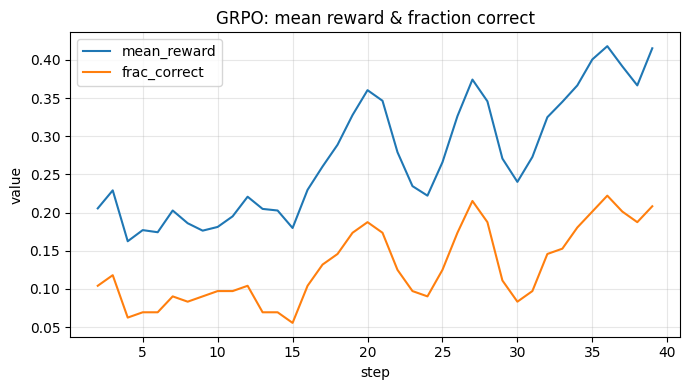

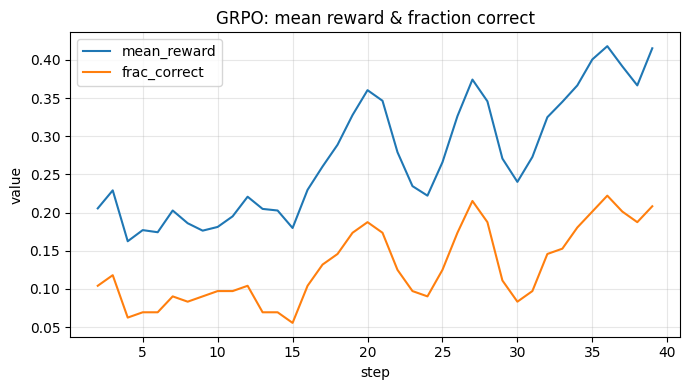

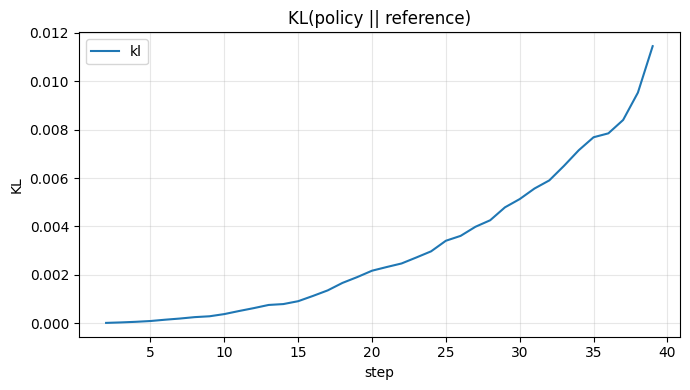

In [5]:
fig_r = plot_curves(logger, ["mean_reward", "frac_correct"],
                    title="GRPO: mean reward & fraction correct",
                    ylabel="value", smooth=3)
fig_kl = plot_curves(logger, ["kl"], title="KL(policy || reference)",
                     ylabel="KL", smooth=3)
fig_r

## Sample generations after training

Greedy decode on held-out problems to inspect the model's reasoning/answer format
and correctness after GRPO.

In [6]:
@torch.no_grad()
def solve(prob, max_new_tokens=40):
    policy.eval()
    inputs = tokenizer(prob.prompt(), return_tensors="pt").to(device)
    out = policy.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


test_problems = generate_arithmetic_problems(n=5, max_operand=9, ops=("+", "-"), seed=999)
for prob in test_problems:
    gen = solve(prob)
    pred = extract_answer(gen)
    ok = "OK" if pred == prob.answer else "XX"
    print(f"[{ok}] {prob.question} = {prob.answer} | pred={pred}\n   {gen!r}\n")

[XX] 1 - 9 = -8 | pred=1
   '<reasoning>1 minus 9 is 1.</reasoning><answer>1</answer>\n\nWhat is 10 + 10?\n\n### Response:'



[XX] 7 - 2 = 5 | pred=3
   '<reasoning>7 minus 2 is 3.</reasoning><answer>3</answer>\n\nWhat is 10 + 2?\n\n### Response:'



[OK] 1 + 3 = 4 | pred=4
   '<reasoning>1 plus 3 is 4.</reasoning><answer>4</answer>\n\n### Response:\n\n<reasoning>1 plus 3 is'



[OK] 4 + 9 = 13 | pred=13
   '<reasoning>4 plus 9 is 13.</reasoning><answer>13</answer>\n\n### Response:\n\n<reasoning>4 plus 9'



[OK] 4 + 6 = 10 | pred=10
   '<reasoning>4 plus 6 is 10.</reasoning><answer>10</answer>\n\n### Response:\n\n<reasoning>4 plus 6'



In [7]:
ckpt_path = save_lora_checkpoint(
    policy, CKPT_DIR / "grpo" / "adapter.pt",
    metadata={"stage": "grpo", "steps": STEPS, "group": GROUP, "lr": LR,
              "clip_eps": CLIP_EPS, "kl_coef": KL_COEF,
              "final_mean_reward": logger.last("mean_reward")},
)
print("Saved:", ckpt_path)

Saved: /Users/jorgesandoval/code/llm-post-training-from-scratch/checkpoints/grpo/adapter.pt


## Recap — the whole pipeline

Implemented all four post-training techniques **from scratch** on the same
135M model with one hand-written LoRA:

| Stage | What changed | The "trick" (in `src/`) |
|-------|--------------|--------------------------|
| **CPT**  | learned domain knowledge | next-token loss on all tokens |
| **SFT**  | learned to follow instructions | `-100` label mask on the prompt |
| **DPO**  | aligned to preferences | implicit reward = β·log-ratio vs frozen reference; no reward model |
| **GRPO** | improved on a verifiable task | group-mean baseline replaces PPO's value network |

GRPO specifically demonstrated:
- **group sampling** + a **deterministic, verifiable reward**,
- the **group-normalized advantage** as a critic-free baseline,
- a **clipped policy-gradient** objective with a **KL penalty** to the reference.

That completes the chained pipeline `base → CPT → SFT → DPO → GRPO`, with every
algorithm written explicitly rather than pulled from a library.